In [1]:
import espressomd
import espressomd.accumulators
import espressomd.observables
import numpy as np

In [2]:

# -------------------------------------------------------------------------
# 1. Physical Parameters from Raikher et al. (Jeffreys Fluid)
# -------------------------------------------------------------------------
kT = 10.0
mass_real = 1.0          # Mass of the tracer particle
mass_virt = 0.01         # Small mass for the auxiliary variable (quasi-overdamped)

gamma_f = 0.5            # Solvent viscosity (Instantaneous friction)
gamma_s = 6.5            # Polymer viscosity (Memory friction)
tau_s   = 1.0           # Relaxation time

# Calculated Spring Constant for the Maxwell Element equivalence
# k = gamma_s / tau_s
k_spring = gamma_s / tau_s


STEPS = 3 *1000 * 333

In [3]:

# -------------------------------------------------------------------------
# 2. ESPResSo System Setup
# -------------------------------------------------------------------------
system = espressomd.System(box_l=[50, 50, 50])
system.time_step = 0.003
system.cell_system.skin = 0.4

# Verify feature is available for per-particle friction
if "THERMOSTAT_PER_PARTICLE" not in espressomd.features():
    raise Exception("Please compile ESPResSo with THERMOSTAT_PER_PARTICLE to use this implementation.")

# Set the global temperature (gamma here is a default, we override it per particle)
system.thermostat.set_langevin(kT=kT, gamma=1.0, seed=42)

# Define the Harmonic Bond (The viscoelastic coupling)
jeffreys_bond = espressomd.interactions.HarmonicBond(k=k_spring, r_0=0.0)
system.bonded_inter.add(jeffreys_bond)


0

In [4]:
def msd_correlator(pids, tau_max):
    pos = espressomd.observables.ParticlePositions(ids=pids)
    pos_corr = espressomd.accumulators.Correlator(
        obs1=pos, tau_lin=16, tau_max=tau_max, delta_N=1,
        corr_operation="square_distance_componentwise", compress1="discard1")
    return pos_corr

def vel_correlator(pids, tau_max):
    vel = espressomd.observables.ParticleVelocities(ids=pids)
    vel_corr = espressomd.accumulators.Correlator(
        obs1=vel, tau_lin=16, tau_max=tau_max, delta_N=1,
        corr_operation="scalar_product", compress1="discard1")
    return vel_corr

In [5]:

# -------------------------------------------------------------------------
# 3. Particle Creation
# -------------------------------------------------------------------------
# Create the Real Particle (Type 0)
real_p = system.part.add(
    pos=[25, 25, 25],
    mass=mass_real,
    type=0,
    gamma=gamma_f  # Sets the solvent friction \gamma_f
)

# Create the Virtual Particle (Type 1)
# Placed at the same position initially
virt_p = system.part.add(
    pos=[25, 25, 25],
    mass=mass_virt,
    type=1,
    gamma=gamma_s  # Sets the polymer friction \gamma_s
)

# Connect them with the spring
real_p.add_bond((jeffreys_bond, virt_p))

# Make sure the virtual particle doesn't interact via LJ/Coulomb with others
# (It should only interact via the bond and the thermostat)
system.non_bonded_inter[0, 1].lennard_jones.set_params(epsilon=0, sigma=0, cutoff=0, shift=0)
system.non_bonded_inter[1, 1].lennard_jones.set_params(epsilon=0, sigma=0, cutoff=0, shift=0)


In [6]:
tau_results = None
msd_results = None
vacf_results = None
# -------------------------------------------------------------------------
# 4. Simulation
# -------------------------------------------------------------------------
print("Equilibrating the system.")
system.integrator.run(1000)
print("Equilibration finished.")

correlator_msd = msd_correlator([real_p.id], STEPS)
correlator_vel = vel_correlator([real_p.id], STEPS)
system.auto_update_accumulators.add(correlator_msd)
system.auto_update_accumulators.add(correlator_vel)


print("Simulating Jeffreys Fluid Brownian Motion...")
system.integrator.run(STEPS)

correlator_msd.finalize()
correlator_vel.finalize()
tau_results = correlator_msd.lag_times()
msd_results = np.sum(correlator_msd.result().reshape([-1, 3]), axis=1)
vacf_results = np.sum(correlator_vel.result().reshape([-1, 1]), axis=1)
# In our setup, both correlators should produce values for the same lag times,
# we therefore do not have to save the lag times twice ...
assert np.array_equal(tau_results, correlator_vel.lag_times())
system.auto_update_accumulators.clear()
system.thermostat.turn_off()

Equilibrating the system.
Equilibration finished.
Simulating Jeffreys Fluid Brownian Motion...


In [7]:
tau_results.shape

(217,)

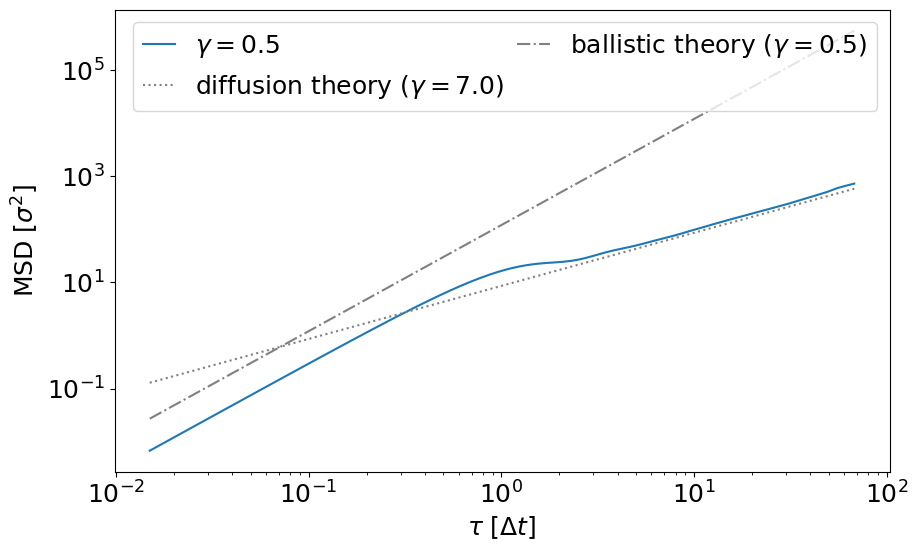

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt

start, end = 5, 100

plt.rcParams.update({'font.size': 18})

plt.figure(figsize=(10, 6))
plt.xlabel(r'$\tau$ [$\Delta t$]')
plt.ylabel(r'MSD [$\sigma^2$]')
# linestyles = ["solid", "dashdot", "dashed", "dotted"]
# for index, (tau, msd) in enumerate(zip(tau_results, msd_results)):
    # We skip the first entry since it's zero by definition and cannot be displayed
    # in a loglog plot. Furthermore, we only look at the first 100 entries due to
    # the high variance for larger lag times.
plt.loglog(tau_results[start:end], msd_results[start:end], label=fr'$\gamma={gamma_f:.1f}$')
# for index, tau in enumerate(tau_results):
plt.loglog(tau_results[start:end], 6*kT/(gamma_f + gamma_s)*tau_results[start:end], linestyle='dotted',
            color="gray", label=fr'diffusion theory ($\gamma={gamma_f + gamma_s:.1f}$)')

plt.loglog(tau_results[start:end], 6*kT/(gamma_f)*(tau_results[start:end] ** 2), linestyle='dashdot',
            color="gray", label=fr'ballistic theory ($\gamma={gamma_f:.1f}$)')
plt.legend(ncol=2, columnspacing=0.5, handlelength=1.3)
plt.show()

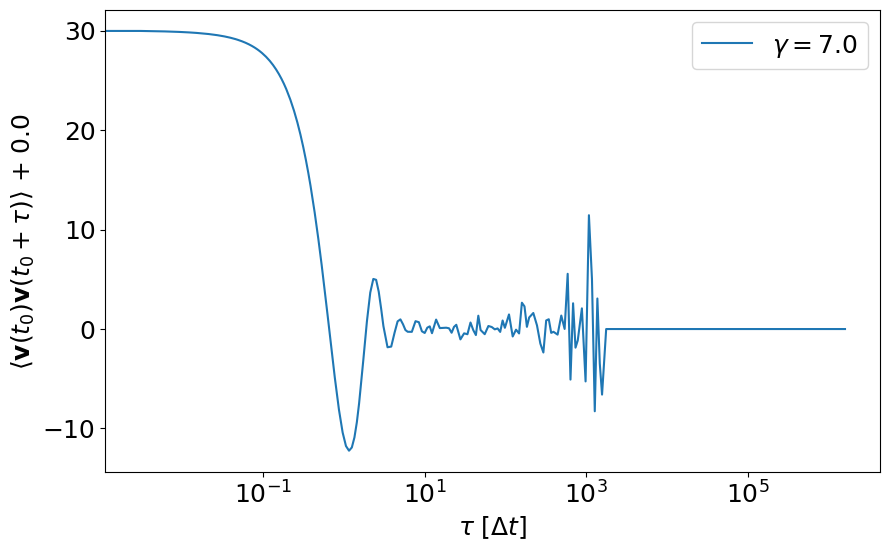

In [9]:
offset = 0.0

plt.figure(figsize=(10, 6))
plt.xlabel(r"$\tau$ [$\Delta t$]")
plt.ylabel(r"$\langle {\bf v}(t_0) {\bf v}(t_0 + \tau) \rangle$" + f" + {offset}")

# plt.xlim([0.004, 2500])
# plt.ylim([0.001, 5])
# for index, (tau, vacf) in enumerate(zip(tau_results, vacf_results)):
plt.semilogx(tau_results, vacf_results + offset, label=fr'$\gamma={gamma_f + gamma_s:.1f}$')
plt.legend()
plt.show()